In [ ]:
!pip install -r requirements.txt

In [ ]:
!pip install imbalanced-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.4/235.4 kB 13.5 MB/s eta 0:00:00


In [ ]:
## import des librairie necessaires :

import os
import cv2
import numpy as np
from glob import glob
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from imblearn.metrics import classification_report_imbalanced, geometric_mean_score
from sklearn.metrics import f1_score
import pandas as pd
from sklearn.preprocessing import StandardScaler
from collections import Counter
import seaborn as sns
import tensorflow as tf
from sklearn.neural_network import MLPClassifier

from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.model_selection import RandomizedSearchCV
from skopt import BayesSearchCV
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from google.colab import drive
drive.mount('/content/drive')

##librairie DEEP LEARNING
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D,Rescaling, GlobalMaxPooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Instancier le modele CNN et l'entrainer avec les données X_train:


## 1. Etapes:

Dans cette partie nous allors appliquer des preprocessing basique à notre jeux de données.

Pour le premier modele nous allons effectuer une classification non supervisé. on utilisera uniquement les données train good pour entrainner le modele et les données test sans good pour tester le modele.

Comme vu dans la partie de l'exploration des données, les images de notre dataset on différentes taille, et des images en couleurs et gris .


* Comme les reseau de neuronne utilise que les images avec la même taille nous allors redimensionner les image de notre jeux de données en entier.
* Aussi, nous allons lire toute les image en couleurs car si on convertis les images en gris  on risque de perdre l'information de la couleurs.
* on normalise aussi les image de 0 et 1 car les reseau de neuronne sont sensible à l'echelle d'entrée. Cette étape est indispensable afin de permet au reseau de neuronne de travailler sur des gradiant initiaux de petite valeurs. aussi certaine fonction d'activation comme sigmoid ont une mielleurs performance avec des données normaliser. et aussi certain fonction d'optimisation travaille mieux avec des données normalisé.


###### **`Fonction pour preprocessing:`**

In [ ]:
## Fonction qui permet de faire les preprocessing necessaires pour l'ensemble des données du dataset:

def preprocessing_all (path, color_mode='rgb'):

    """ Fonction qui permet de faire les preprocessing basique pour lancer un modele de reseau de neuronne
      les argument:
            path: le chemin de l'emplacement des données
            color_mode = 'rgb': convertir toute les image en RGB même les images initialement en gris
                         afin de ne pas perdre l'information de la couleurs.

            Normalise: on normalise les images en remplacant tout les pixels avec des valeurs de 0 à 1
              """

    ## stocker les images prétraité:
    img_prp= []
    ##lire tout les images de dataset
    img_paths = glob(os.path.join(path, "**", "*.*"), recursive=True)

    ## afficher le nombre d'image trouver par categorie:
    print(f"Nombre d'images trouvées dans {path} : {len(img_paths)}")

    for file_path in img_paths:

        ## Lire et modifier l'image la couleur de gray en RGB:
        if color_mode == 'rgb':
            img = cv2.imread(file_path, cv2.IMREAD_COLOR)
            if img is None:
                continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        else:
            img = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue
            img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

        ##redimentionnement des taille:
        img=cv2.resize(img, (256,256) )


        ##Normalisation:
        img=img.astype('float32')/255.

        ##ajouter le resultats dans la liste :
        img_prp.append(img)




    ##convertir la liste en tableau numpy:
    X = np.array(img_prp)


    return X




###### **`Création de X_train et y_train pour l'ensembel du dataset:`**

Dans cett partie, nous avons traité l'ensemble des catégroie de dataset afin de regrouper les image avec et sans anoamlies et créer les labels 0 pour sans anomalie et 1 avec anoamalies:

In [ ]:
##Appliquer les preprocessing pour l'ensemble des données de train/ good:

## pour cela nous allons utiliser la methode glob pour lire les fichier de train de l'ensemble des pieces :

path= r"C:/Users/hanou/OneDrive/Formation_DS/Projet/mvtec_anomaly_detection/*/train/good"
train_path= glob(path)

X_train_good= []
y_train_good=[]
for category_path in train_path:
    X_cate= preprocessing_all(category_path)
    y_anom = np.zeros(len(X_cate), dtype=np.int64)
    X_train_good.append(X_cate)
    y_train_good.append(y_anom)

X_train_good= np.concatenate(X_train_good, axis=0)
X_train_good= np.concatenate(y_train_good, axis=0)



Nombre d'images trouvées dans C:/Users/hanou/OneDrive/Formation_DS/Projet/mvtec_anomaly_detection\bottle\train\good : 209
Nombre d'images trouvées dans C:/Users/hanou/OneDrive/Formation_DS/Projet/mvtec_anomaly_detection\cable\train\good : 224
Nombre d'images trouvées dans C:/Users/hanou/OneDrive/Formation_DS/Projet/mvtec_anomaly_detection\capsule\train\good : 219
Nombre d'images trouvées dans C:/Users/hanou/OneDrive/Formation_DS/Projet/mvtec_anomaly_detection\carpet\train\good : 280
Nombre d'images trouvées dans C:/Users/hanou/OneDrive/Formation_DS/Projet/mvtec_anomaly_detection\grid\train\good : 264
Nombre d'images trouvées dans C:/Users/hanou/OneDrive/Formation_DS/Projet/mvtec_anomaly_detection\hazelnut\train\good : 391
Nombre d'images trouvées dans C:/Users/hanou/OneDrive/Formation_DS/Projet/mvtec_anomaly_detection\leather\train\good : 245
Nombre d'images trouvées dans C:/Users/hanou/OneDrive/Formation_DS/Projet/mvtec_anomaly_detection\metal_nut\train\good : 220
Nombre d'images trou

In [ ]:
print(X_train.shape)
print(X_train.dtype)


(3629, 256, 256, 3)
float32


###### **`Création de X_test et y_test pour l'ensemble du dataset:`**


In [ ]:
## liste pour stocker X_test et y_test
X_test= []
y_test= []


## chemin du dataset:
path= r"C:/Users/hanou/OneDrive/Formation_DS/Projet/mvtec_anomaly_detection"

## création du chemin pour chaque categorie du dataset MVTec
categories= glob(path+ "/*")

##faire une boucle pour créer
for cat in categories:
    test_path = cat + "/test"
    if not os.path.exists(test_path): ##verifier si une categorie n'a pas de dossier
        continue

    # GOOD → label 0
    good_path = test_path + "/good"
    if os.path.exists(good_path):
        X_good = preprocessing_all(good_path)  ##appliquer les preprocessing au données de test/good
        y_good = np.zeros(len(X_good), dtype=np.int64)  ## création d'un label 0 pour les données good et les stocker dans y_test
        X_test.append(X_good)
        y_test.append(y_good)

    # ANOMALIES → label 1
    for anomaly in os.listdir(test_path):
        if anomaly == "good":  ##on ignore le dossier good car on l'avait déja traité et stocker.
            continue

        ## création d'un nouveau path pour l'ensemble des anomalie de chauq piéces
        anomaly_path = test_path + "/" + anomaly
        if os.path.isdir(anomaly_path):  ## on verifier que c'est bien un dossier.
            X_anom = preprocessing_all(anomaly_path)  ## on applique les preprocessing instancier dans la focntion preprocessing_all
            y_anom = np.ones(len(X_anom), dtype=np.int64)  ## on ajoute un label au image avec anomalie de valeur 1
            X_test.append(X_anom)
            y_test.append(y_anom)

##faire la concaténation pour créer X_test et y_test final
X_test = np.concatenate(X_test, axis=0)
y_test = np.concatenate(y_test, axis=0)

print(X_test.shape, y_test.shape)


Nombre d'images trouvées dans C:/Users/hanou/OneDrive/Formation_DS/Projet/mvtec_anomaly_detection\bottle/test/good : 20
Nombre d'images trouvées dans C:/Users/hanou/OneDrive/Formation_DS/Projet/mvtec_anomaly_detection\bottle/test/broken_large : 20
Nombre d'images trouvées dans C:/Users/hanou/OneDrive/Formation_DS/Projet/mvtec_anomaly_detection\bottle/test/broken_small : 22
Nombre d'images trouvées dans C:/Users/hanou/OneDrive/Formation_DS/Projet/mvtec_anomaly_detection\bottle/test/contamination : 21
Nombre d'images trouvées dans C:/Users/hanou/OneDrive/Formation_DS/Projet/mvtec_anomaly_detection\cable/test/good : 58
Nombre d'images trouvées dans C:/Users/hanou/OneDrive/Formation_DS/Projet/mvtec_anomaly_detection\cable/test/bent_wire : 13
Nombre d'images trouvées dans C:/Users/hanou/OneDrive/Formation_DS/Projet/mvtec_anomaly_detection\cable/test/cable_swap : 12
Nombre d'images trouvées dans C:/Users/hanou/OneDrive/Formation_DS/Projet/mvtec_anomaly_detection\cable/test/combined : 11
Nomb

###### **`Modele CNN Avec recostruction d'image:`**


In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D

##données inputs:
input_shape= (256,256,3)
inputs= Input(shape= input_shape)

## créer un encoder:
layer1= Conv2D(8, (3,3), activation='relu', padding='same')(inputs)
layer2= MaxPooling2D((2,2), padding=('same')) (layer1)
layer3= Conv2D(16, (3,3), activation='relu', padding='same')(layer2)
layer4= MaxPooling2D((2,2), padding=('same')) (layer3)
layer5= Conv2D(32, (3,3), activation='relu', padding='same')(layer4)
layer6= MaxPooling2D((2,2), padding=('same')) (layer5)

## créer un decoder qui permet de reconstruire l'image :
layer7 = Conv2D(32, (3,3), activation='relu', padding='same')(layer6)
layer8 = UpSampling2D((2,2))(layer7)
layer9 = Conv2D(16, (3,3), activation='relu', padding='same')(layer8)
layer10 = UpSampling2D((2,2))(layer9)
layer11 = Conv2D(8, (3,3), activation='relu', padding='same')(layer10)
layer12 = UpSampling2D((2,2))(layer11)

##reconstruction final:
outputs= Conv2D(3, (3,3), activation='sigmoid', padding='same')(layer12)

model= Model(inputs, outputs)
##entrainnement du modele
model.compile(optimizer='adam', loss='mse')


##afficher le summary:

model.summary()



Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 256, 256, 8)    │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 128, 128, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 128, 128, 16)   │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_36 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_9 (UpSampling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 64, 64, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_10 (UpSampling2D) │ (None, 128, 128, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_38 (Conv2D)              │ (None, 128, 128, 8)    │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_11 (UpSampling2D) │ (None, 256, 256, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_39 (Conv2D)              │ (None, 256, 256, 3)    │           219 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,283 (83.14 KB)

 Trainable params: 21,283 (83.14 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#### entrainnement du modele  en utilisant epochs=20, batch_size=32 et on laisse 20% pour les données de validation

history = model.fit(X_train, X_train, epochs=20, batch_size=32, validation_split=0.2)


Epoch 1/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 59s 562ms/step - loss: 0.0261 - val_loss: 0.0123
Epoch 2/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 44s 485ms/step - loss: 0.0073 - val_loss: 0.0116
Epoch 3/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 29s 315ms/step - loss: 0.0060 - val_loss: 0.0060
Epoch 4/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 31s 341ms/step - loss: 0.0049 - val_loss: 0.0045
Epoch 5/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 27s 292ms/step - loss: 0.0046 - val_loss: 0.0038
Epoch 6/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 29s 313ms/step - loss: 0.0043 - val_loss: 0.0036
Epoch 7/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 54s 599ms/step - loss: 0.0041 - val_loss: 0.0034
Epoch 8/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 78s 853ms/step - loss: 0.0039 - val_loss: 0.0034
Epoch 9/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 43s 465ms/step - loss: 0.0038 - val_loss: 0.0032
Epoch 10/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 36s 393ms/step - loss: 0.0038 - val_loss: 0.0033
Epoch 11/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 29s 323ms/step - loss: 0.0037 - val_loss: 0.0031
Epoch 12/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 31

#### Interprétation :

* Si train loss et val_loss descendent ensemble → le modèle apprend et généralise bien.

* Si train loss diminue mais val_loss stagne ou augmente → surapprentissage.

* Si les deux restent stables ou n’évoluent pas → le modèle n’apprend pas, peut-être problème d’architecture ou de taux d’apprentissage.

 On observe que la loss diminue progressivement au fil des epochs, ce qui indique que le modèle apprend correctement. La val_loss diminue également, et reste très proche de la loss, ce qui montre que le modèle généralise bien et ne présente pas de surapprentissage.

 La baisse conjointe de la loss et de la val_loss, avec un écart faible entre les deux, montre que l’autoencoder apprend efficacement la distribution des données normales. Cette stabilité suggère que le modèle est bien entraîné et adapté à une détection d’anomalies basée sur l’erreur de reconstruction.

 On remarque que la valeur minimale de la loss est atteinte autour de l’epoch 13. Par la suite, les variations observées correspondent à une phase de convergence, où la loss oscille légèrement autour de cette valeur sans tendance nette à la hausse, ce qui indique que le modèle a atteint un optimum.

 Afin d’éviter un entraînement inutile après la phase de convergence, un Early Stopping peut être mis en place pour interrompre l’apprentissage lorsque la val_loss cesse de diminuer, garantissant ainsi un modèle optimal et limitant le risque de surapprentissage.

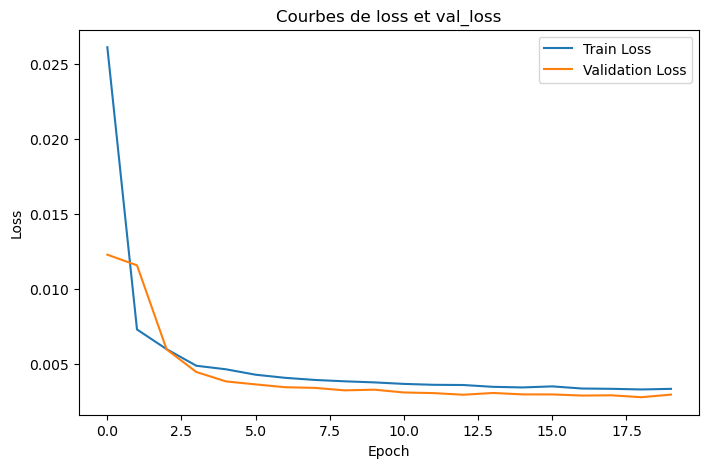

In [ ]:
## afficher la coube de l'evolution de la fonction de la perte loss et celle de Val_loss:

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Courbes de loss et val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


#####

In [ ]:
##faire les prediction avec X_test:
X_pred= model.predict(X_test)
## On calcul l'erreur de recontruction de chaque image de test:
reconstruction_error = np.mean(np.square(X_test - X_pred),axis=(1, 2, 3) )


# Seuil : 95ème percentile des images normales
threshold = np.percentile(reconstruction_error[y_test==0], 95)
## le seuil doit représenter le comportement normal du modèle, pas celui des anomalies.
print("Seuil de détection:", threshold)

# on applique le seuil au données des erreurs de construction:
y_pred = (reconstruction_error > threshold).astype(int)


54/54 ━━━━━━━━━━━━━━━━━━━━ 7s 117ms/step
Seuil de détection: 0.015232052


##### Évaluer la performance:

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print(f"Accuracy : {accuracy_score(y_test, y_pred):.2f}")
print(f"Precision: {precision_score(y_test, y_pred):.2f}")
print(f"Recall: {recall_score(y_test, y_pred): .2f}")
print(f"F1-score: {f1_score(y_test, y_pred):.2f}")
print(f"Confusion Matrix:\n {confusion_matrix(y_test, y_pred)}")

Accuracy : 0.29
Precision: 0.67
Recall:  0.04
F1-score: 0.07
Confusion Matrix:
 [[ 443   24]
 [1209   49]]
